## Study of differential state-space model Diff-UMamba in out-of-distribution dynamics with Lorenz Attractor via Comparison with nn-UNet and UMamba

The main motivation of the surrent study is envistigating the capacity of the recently proposed Noise Reduction Module (NRM) in Diff-UMamba, together with comparison of this model with the one which does not have differential component (UMamba) and the baseline model nn-UNet. The latter is the baseline for both Mamba-based models, Diff-UMamba and UMamba, commonly used in medical data analysis.

Sources:

1. E. Lorenz: Deterministic nonperiodic flow., J. Atmos. Sci. 20(2) 1963.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

drive_path = '/content/drive/MyDrive/colab_packages'
os.makedirs(drive_path, exist_ok=True)
sys.path.append(drive_path)

!pip install --target=$drive_path "causal-conv1d>=1.4.0" --no-build-isolation
!pip install --target=$drive_path "mamba-ssm" --no-build-isolation
!pip install --target=$drive_path nnunetv2

  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 106.0 MB/s eta 0:00

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Using cached torch-2.13.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached triton-3.7.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.9 MB/s eta 0:00:00
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached filelock-3.29.7-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.6.0-py3-no

In [ ]:
!pip install -q nibabel scipy numpy

import numpy as np
from scipy.integrate import solve_ivp
import nibabel as nib
import os, json, shutil

Based on classical formulation of the Lorenz attractor, we can define functions, which are describing two butterflies according to the following formulas (Lorenz, 1963):

$dx = σ(y-x)$

$dy = x (ρ - z) - y$

$dz = x y - β z$

In [2]:
def lorenz_rhs(t, state, sigma, rho, beta):
    x, y, z = state
    # standard Lorenz equations
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

def simulate_lorenz(sigma, rho, beta, x0, t_span=(0, 30), dt=0.01, discard=5.0):
    """
    Integrates the Lorenz system and discards an initial transient so the trajectory has settled onto the attractor
    (or onto whatever the long-term behavior is for that parameter regime).
    """
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(
        lorenz_rhs, t_span, x0, args=(sigma, rho, beta),
        t_eval=t_eval, method='RK45', rtol=1e-7, atol=1e-9
    )
    keep = sol.t >= discard
    traj = sol.y[:, keep].T  # shape (N, 3)
    if traj.shape[0] < 100 or not np.all(np.isfinite(traj)):
        return None  # solver diverged or produced a degenerate trajectory
    return traj

Then, in order to match the input format for the baseline nn-UNet architecture, which is the same for al three networks we are going to explore, we need to transform the trajectories into 3D images.

In [3]:
def voxelize(traj, grid, bounds):
    """
    bounds: array [[xmin,ymin,zmin],[xmax,ymax,zmax]] — FIXED across all
    ID/OOD cases so voxel (i,j,k) means the same physical region everywhere.
    Returns:
      density   : normalized visitation-count volume (channel 0000)
      speed_map : normalized mean local speed per voxel (channel 0001)
      idx       : per-timestep voxel index, reused for labeling
    """
    idx = ((traj - bounds[0]) / (bounds[1] - bounds[0]) * grid).astype(int)
    idx = np.clip(idx, 0, grid - 1)

    density   = np.zeros((grid,)*3, dtype=np.float32)
    speed_acc = np.zeros((grid,)*3, dtype=np.float32)
    speed_cnt = np.zeros((grid,)*3, dtype=np.float32)

    vel = np.gradient(traj, axis=0)
    speed = np.linalg.norm(vel, axis=1)

    for (i, j, k), s in zip(idx, speed):
        density[i, j, k]   += 1
        speed_acc[i, j, k] += s
        speed_cnt[i, j, k] += 1

    speed_map = np.divide(speed_acc, speed_cnt,
                           out=np.zeros_like(speed_acc), where=speed_cnt > 0)
    density   = density   / (density.max()   + 1e-8)
    speed_map = speed_map / (speed_map.max() + 1e-8)
    return density, speed_map, idx

In [4]:
def make_labels(idx, bounds, grid):
    """
    0 = background (never visited)
    1 = right wing  (x >= 0 lobe)
    2 = left wing   (x <  0 lobe)
    3 = transition  (voxel visited by trajectory points from BOTH lobes,
                     e.g. near the central saddle where switches happen)
    """
    label = np.zeros((grid,)*3, dtype=np.uint8)
    x_centers = (idx[:, 0] + 0.5) / grid * (bounds[1,0] - bounds[0,0]) + bounds[0,0]
    wing = np.where(x_centers >= 0, 1, 2)

    for (i, j, k), w in zip(idx, wing):
        if label[i, j, k] == 0:
            label[i, j, k] = w
        elif label[i, j, k] != w:
            label[i, j, k] = 3
    return label

In [5]:
GRID = 32
GLOBAL_BOUNDS = np.array([[-30, -35, 0], [30, 35, 400]], dtype=np.float32)

def make_case(sigma, rho, beta, seed, grid=GRID, bounds=GLOBAL_BOUNDS, t_span=(0, 30)):
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(-15, 15, 3)  # random initial condition -> dataset diversity
    traj = simulate_lorenz(sigma, rho, beta, x0, t_span=t_span)
    if traj is None:
        return None
    density, speed_map, idx = voxelize(traj, grid, bounds)
    label = make_labels(idx, bounds, grid)
    return density, speed_map, label

In [6]:
# Standard chaotic butterfly = in-distribution training regime
ID_PARAMS = dict(sigma=10.0, rho=28.0, beta=8/3)

# Each OOD regime shifts the *dynamics*, not just noise on the image:
OOD_PARAMS = {
    "fixed_point":     dict(sigma=10.0, rho=13.0,  beta=8/3),  # rho<24.74: no chaos, spirals to ONE fixed point -> only one wing ever visited
    "transient_chaos": dict(sigma=10.0, rho=99.96, beta=8/3),  # near the transient-chaos boundary, very different transient statistics
    "large_rho_chaos": dict(sigma=10.0, rho=350.0, beta=8/3),  # different, noisier chaotic regime, much larger z-extent
    "reshaped_attractor": dict(sigma=20.0, rho=28.0, beta=1.0), # chaotic, but a geometrically different attractor shape
}

In [7]:
def build_dataset(root, dataset_name, params, n_cases, seed_offset=0):
    """
    Creates:
      root/dataset_name/
        dataset.json
        imagesTr/  CASE_0000.nii.gz (density), CASE_0001.nii.gz (speed)
        labelsTr/  CASE.nii.gz
    """
    ds_dir = os.path.join(root, dataset_name)
    os.makedirs(os.path.join(ds_dir, 'imagesTr'), exist_ok=True)
    os.makedirs(os.path.join(ds_dir, 'labelsTr'), exist_ok=True)

    affine = np.eye(4)  # identity affine: we don't need real-world spacing/orientation here
    case_names = []
    i = 0
    attempts = 0
    while len(case_names) < n_cases and attempts < n_cases * 3:
        out = make_case(**params, seed=seed_offset + attempts)
        attempts += 1
        if out is None:
            continue
        density, speed_map, label = out
        cid = f'{dataset_name}_{i:04d}'
        nib.save(nib.Nifti1Image(density, affine),
                  os.path.join(ds_dir, 'imagesTr', f'{cid}_0000.nii.gz'))
        nib.save(nib.Nifti1Image(speed_map, affine),
                  os.path.join(ds_dir, 'imagesTr', f'{cid}_0001.nii.gz'))
        nib.save(nib.Nifti1Image(label, affine),
                  os.path.join(ds_dir, 'labelsTr', f'{cid}.nii.gz'))
        case_names.append(cid)
        i += 1

    dataset_json = {
        "channel_names": {"0": "noNorm", "1": "noNorm"},  # "noNorm" = don't apply CT-style intensity norm; use per-channel z-scoring
        "labels": {"background": 0, "right_wing": 1, "left_wing": 2, "transition": 3},
        "numTraining": len(case_names),
        "file_ending": ".nii.gz"
    }
    with open(os.path.join(ds_dir, 'dataset.json'), 'w') as f:
        json.dump(dataset_json, f, indent=2)

    print(f"{dataset_name}: {len(case_names)} cases written to {ds_dir}")
    return case_names

In [8]:
NNUNET_RAW = '/content/nnUNet_raw'   # set this to wherever you point nnUNet_raw env var

# ID training set (this is what you train Diff-UMamba / U-Mamba / nnU-Net on)
build_dataset(NNUNET_RAW, 'Dataset001_LorenzID', ID_PARAMS, n_cases=120)

# One separate OOD dataset per shifted regime (same format -> zero code changes
# needed on the model side, only the input folder changes at inference time)
for i, (name, params) in enumerate(OOD_PARAMS.items(), start=2):
    build_dataset(NNUNET_RAW, f'Dataset{i:03d}_LorenzOOD_{name}', params, n_cases=40, seed_offset=10_000*i)

Dataset001_LorenzID: 120 cases written to /content/nnUNet_raw/Dataset001_LorenzID
Dataset002_LorenzOOD_fixed_point: 40 cases written to /content/nnUNet_raw/Dataset002_LorenzOOD_fixed_point
Dataset003_LorenzOOD_transient_chaos: 40 cases written to /content/nnUNet_raw/Dataset003_LorenzOOD_transient_chaos
Dataset004_LorenzOOD_large_rho_chaos: 40 cases written to /content/nnUNet_raw/Dataset004_LorenzOOD_large_rho_chaos
Dataset005_LorenzOOD_reshaped_attractor: 40 cases written to /content/nnUNet_raw/Dataset005_LorenzOOD_reshaped_attractor


In [9]:
os.environ['nnUNet_raw'] = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/nnUNet_results'
os.makedirs(os.environ['nnUNet_preprocessed'], exist_ok=True)
os.makedirs(os.environ['nnUNet_results'], exist_ok=True)

# reload one case to confirm shapes/dtypes look right
d = nib.load(f'{NNUNET_RAW}/Dataset001_LorenzID/imagesTr/Dataset001_LorenzID_0000_0000.nii.gz').get_fdata()
l = nib.load(f'{NNUNET_RAW}/Dataset001_LorenzID/labelsTr/Dataset001_LorenzID_0000.nii.gz').get_fdata()
print(d.shape, d.dtype, d.min(), d.max())
print(l.shape, np.unique(l))

(32, 32, 32) float64 0.0 1.0
(32, 32, 32) [0. 1. 2.]


In [11]:
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: needed for 3d projection

LABEL_COLORS = {0: (0.85, 0.85, 0.85), 1: 'tab:red', 2: 'tab:blue', 3: 'tab:green'}
LABEL_NAMES  = {0: 'background', 1: 'right_wing', 2: 'left_wing', 3: 'transition'}

def visualize_case(traj, idx, label, density, grid=GRID, title='Lorenz case'):
    """
    traj, idx, label, density: outputs from make_case() -- you'll need to
    return traj and idx from make_case (or recompute idx via voxelize)
    if you want to call this directly on a stored case.
    """
    point_labels = label[idx[:,0], idx[:,1], idx[:,2]]

    fig = plt.figure(figsize=(14, 5))

    # (1) raw 3D trajectory colored by which wing each point belongs to
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    for cls in [1, 2, 3]:
        mask = point_labels == cls
        if mask.sum() == 0:
            continue
        ax1.scatter(traj[mask,0], traj[mask,1], traj[mask,2],
                    s=1, color=LABEL_COLORS[cls], label=LABEL_NAMES[cls])
    ax1.set_title(f'{title}\ntrajectory colored by wing label')
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
    ax1.legend(markerscale=8, fontsize=8)

    # (2) a mid-depth slice of the density "image" volume (what the network sees)
    mid = grid // 2
    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(density[:, :, mid].T, origin='lower', cmap='inferno')
    ax2.set_title(f'density volume, axial slice z-idx={mid}')
    plt.colorbar(im2, ax=ax2, fraction=0.046)

    # (3) the same slice of the segmentation label volume (what the network predicts)
    ax3 = fig.add_subplot(1, 3, 3)
    cmap = matplotlib.colors.ListedColormap([LABEL_COLORS[c] for c in [0,1,2,3]])
    im3 = ax3.imshow(label[:, :, mid].T, origin='lower', cmap=cmap, vmin=0, vmax=3)
    ax3.set_title(f'label volume, axial slice z-idx={mid}')
    cbar = plt.colorbar(im3, ax=ax3, fraction=0.046, ticks=[0,1,2,3])
    cbar.ax.set_yticklabels([LABEL_NAMES[c] for c in [0,1,2,3]])

    plt.tight_layout()
    plt.show()

In [12]:
def make_case(sigma, rho, beta, seed, grid=GRID, bounds=GLOBAL_BOUNDS, t_span=(0, 30)):
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(-15, 15, 3)
    traj = simulate_lorenz(sigma, rho, beta, x0, t_span=t_span)
    if traj is None:
        return None
    density, speed_map, idx = voxelize(traj, grid, bounds)
    label = make_labels(idx, bounds, grid)
    return density, speed_map, label, traj, idx   # <-- now returns 5 items

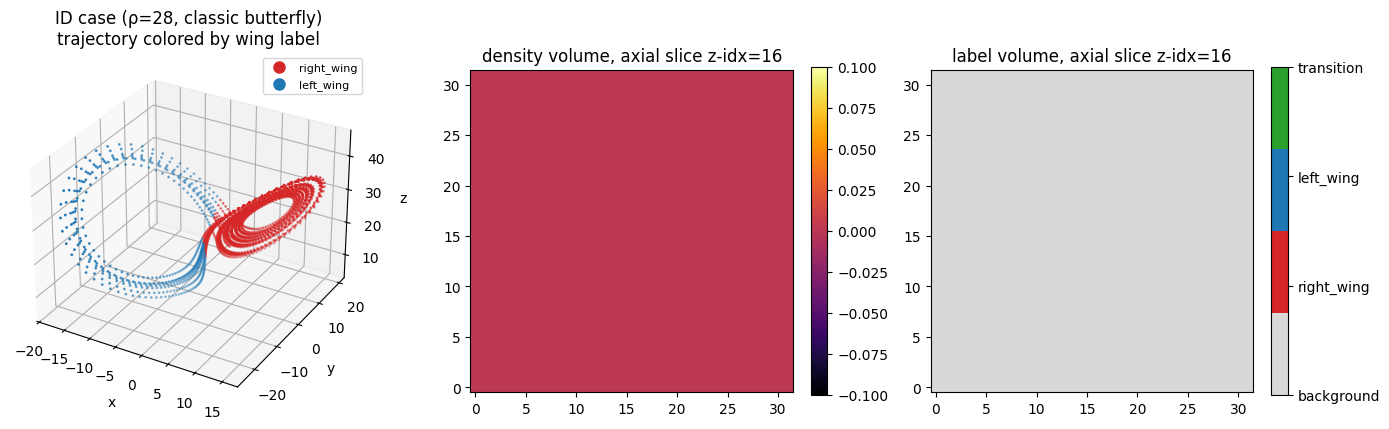

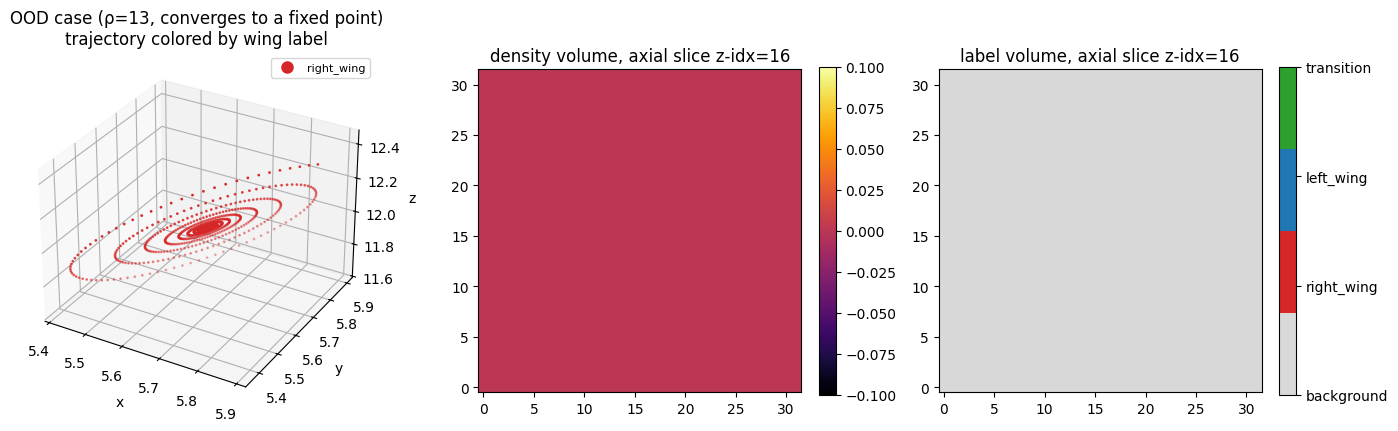

In [15]:
density, speed_map, label, traj, idx = make_case(**ID_PARAMS, seed=0)
visualize_case(traj, idx, label, density, title='ID case (ρ=28, classic butterfly)')

density_o, speed_map_o, label_o, traj_o, idx_o = make_case(**OOD_PARAMS['fixed_point'], seed=0)
visualize_case(traj_o, idx_o, label_o, density_o, title='OOD case (ρ=13, converges to a fixed point)')

### **Training**

In [1]:
!pip install "causal-conv1d>=1.4.0" --no-build-isolation
!pip install "mamba-ssm" --no-build-isolation

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 2.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This

In [2]:
!pip install nnunetv2

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 10.8 MB/s eta 0:00:0

In [2]:
!nnUNetv2_plan_and_preprocess --help

usage: nnUNetv2_plan_and_preprocess [-h] [-d D [D ...]] [-fpe FPE]
                                    [-npfp NPFP] [--verify_dataset_integrity]
                                    [--no_pp] [--clean] [-pl PL]
                                    [-gpu_memory_target GPU_MEMORY_TARGET]
                                    [-preprocessor_name PREPROCESSOR_NAME]
                                    [-overwrite_target_spacing OVERWRITE_TARGET_SPACING [OVERWRITE_TARGET_SPACING ...]]
                                    [-overwrite_plans_name OVERWRITE_PLANS_NAME]
                                    [-c C [C ...]] [-np NP [NP ...]]
                                    [--verbose] [--no_pbar]

options:
  -h, --help            show this help message and exit
  -d D [D ...]          [REQUIRED] List of dataset IDs. Example: 2 4 5. This
                        will run fingerprint extraction, experiment planning
                        and preprocessing for these datasets. Can of course
              

In [16]:
!pip install -q nnunetv2 mamba-ssm causal-conv1d
!nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity
!nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainerDiffUMamba

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
/bin/bash: line 1: nnUNetv2_plan_and_preprocess: command not found
/bin/bash: line 1: nnUNetv2_train: command not found
